In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import torch

# Step 1: Use glob to find all files matching the pattern '*/final_results.csv'
main_path = "/gpfs/commons/home/kisaev/Leaflet-private/temp/sep11sim"
file_paths = glob.glob(os.path.join(main_path, '*/final_results.csv'))

# Check if file paths are found correctly
print(f"Found {len(file_paths)} files.")

# Step 2: Read all CSV files into a list of dataframes
dataframes = [pd.read_csv(file) for file in file_paths]

# Step 3: Concatenate all dataframes into a single dataframe
combined_df = pd.concat(dataframes, ignore_index=True)

Found 30 files.


In [2]:
combined_df.head()

,proportion_negative,K,use_global_prior,input_conc,learning_rate,avg_corr,median_corr,min_corr,correlation_diff,auc_score,optimal_threshold,accuracy,precision,recall,false_positives,false_negatives,silhouette_avg,cell_type_column,silhouette_NMF,input_conc.1
0,0.5,20,False,inf,0.1,0.938591,0.938591,0.938591,0.871912,0.975822,4.158156,0.962343,0.925874,0.998492,106,2,0.919724,NaN,0.001782,inf
1,0.5,2,True,inf,0.1,0.999025,0.999025,0.999025,0.878731,0.976996,1.062199,0.924250,0.838878,0.961372,1109,232,0.986640,NaN,0.000054,inf
2,0.9,2,False,5405.282,0.1,0.999621,0.999621,0.999621,0.508637,0.994508,1.285808,0.977336,0.752852,1.000000,65,0,0.959289,NaN,0.000048,5405.282
3,0.9,20,False,inf,0.1,0.371655,0.371655,0.371655,0.507650,0.988037,4.118975,0.914226,0.520792,0.985019,242,4,-0.034077,NaN,-0.031153,inf
4,0.5,17,True,inf,0.1,0.886508,0.886508,0.886508,0.775062,0.925390,1.777344,0.860396,0.818713,0.896717,1488,774,0.833427,cell_type,0.024846,inf


In [3]:
# Remove the extra input_conc column
combined_df = combined_df.drop(columns=["input_conc.1"])

In [4]:
# Create new likelihood column based on input_conc
combined_df["likelihood"] = combined_df["input_conc"].apply(lambda x: "binomial" if x == float('inf') else "beta0-binomial")

In [5]:
combined_df['combined_prior_input'] = combined_df['use_global_prior'].astype(str) + '-' + combined_df['likelihood']

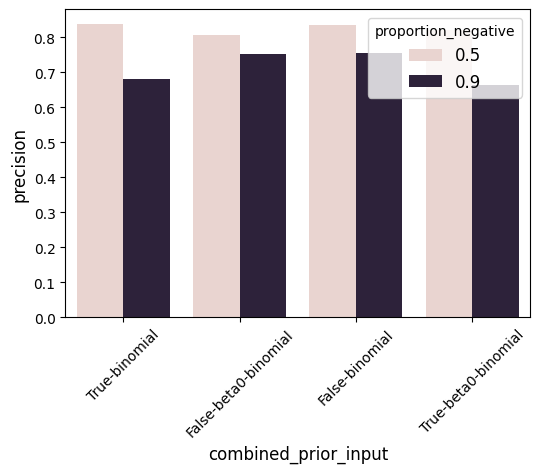

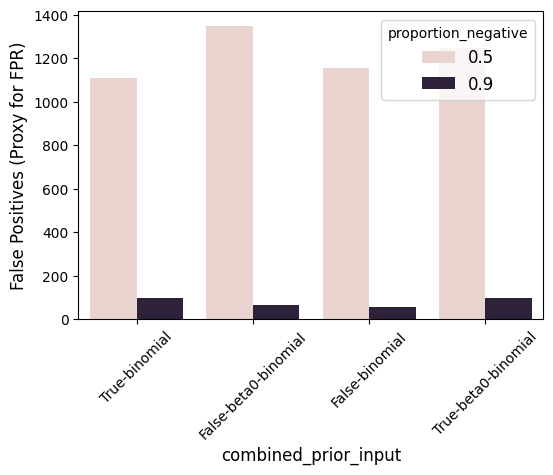

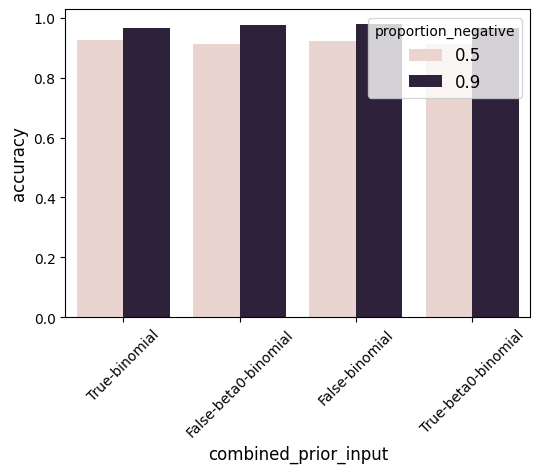

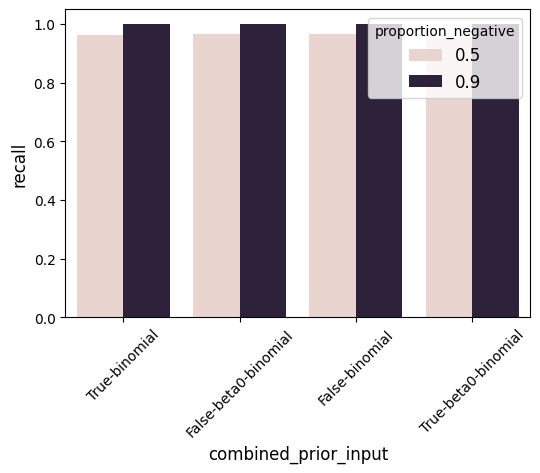

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set font size for all elements
plt.rcParams.update({
    'axes.titlesize': 14,    # Title font size
    'axes.labelsize': 12,    # Axis label font size
    'xtick.labelsize': 10,   # X-axis tick label font size
    'ytick.labelsize': 10,   # Y-axis tick label font size
    'legend.fontsize': 12    # Legend font size
})

# Step 1: Filter the dataframe to include only K=2
df_k2 = combined_df[combined_df['K'] == 2]

# Precision 
plt.figure(figsize=(6, 4))  # Adjust figure size to make it smaller
sns.barplot(x='combined_prior_input', y='precision', hue='proportion_negative', data=df_k2)
plt.xticks(rotation=45)  # Rotate x-axis tick labels
plt.show()

# False Positive Rate (using false positives directly)
plt.figure(figsize=(6, 4))
sns.barplot(x='combined_prior_input', y='false_positives', hue='proportion_negative', data=df_k2)
plt.ylabel('False Positives (Proxy for FPR)')
plt.xticks(rotation=45)  # Rotate x-axis tick labels
plt.show()

# Accuracy
plt.figure(figsize=(6, 4))
sns.barplot(x='combined_prior_input', y='accuracy', hue='proportion_negative', data=df_k2)
plt.xticks(rotation=45)  # Rotate x-axis tick labels
plt.show()

# Recall 
plt.figure(figsize=(6, 4))
sns.barplot(x='combined_prior_input', y='recall', hue='proportion_negative', data=df_k2)
plt.xticks(rotation=45)  # Rotate x-axis tick labels
plt.show()


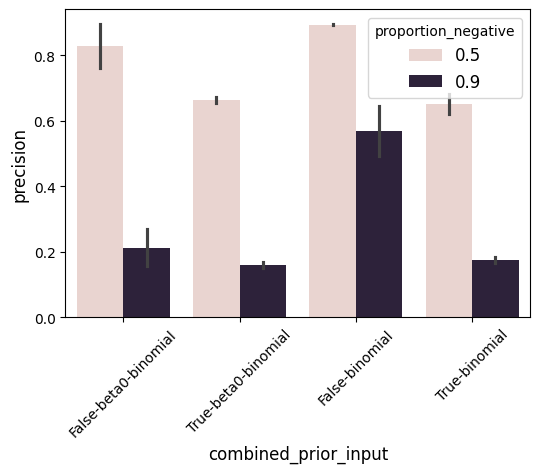

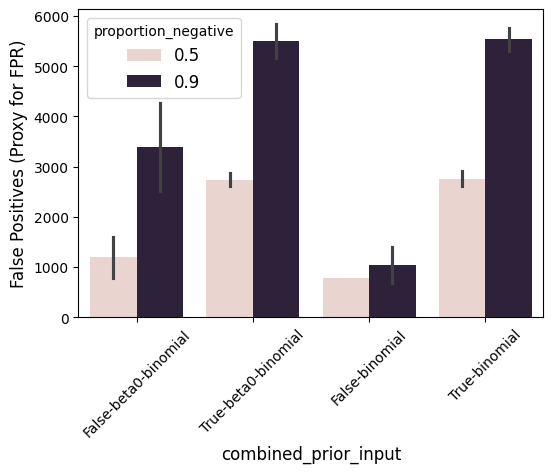

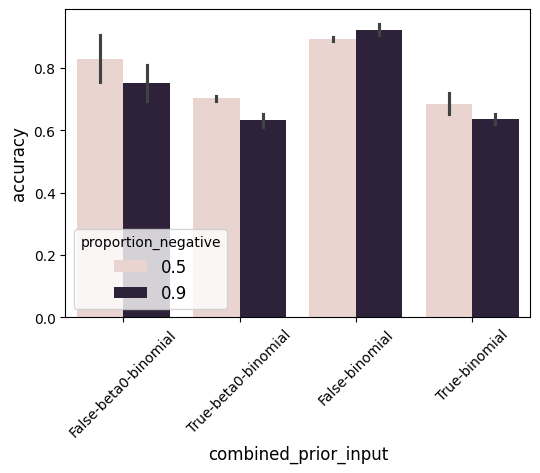

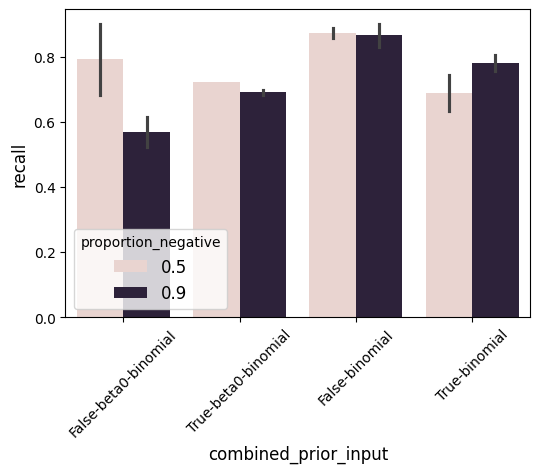

In [14]:
# Step 1: Filter the dataframe to include only K=17
df_k17 = combined_df[combined_df['K'] == 17]

# Precision 
plt.figure(figsize=(6, 4))
sns.barplot(x='combined_prior_input', y='precision', hue='proportion_negative', data=df_k17)
plt.xticks(rotation=45)  # Rotate x-axis tick labels
plt.show()

# False Positive Rate (using false positives directly)
plt.figure(figsize=(6, 4))
sns.barplot(x='combined_prior_input', y='false_positives', hue='proportion_negative', data=df_k17)
plt.ylabel('False Positives (Proxy for FPR)')
plt.xticks(rotation=45)  # Rotate x-axis tick labels
plt.show()

# Accuracy
plt.figure(figsize=(6, 4))
sns.barplot(x='combined_prior_input', y='accuracy', hue='proportion_negative', data=df_k17)
plt.xticks(rotation=45)  # Rotate x-axis tick labels
plt.show()

# Recall 
plt.figure(figsize=(6, 4))
sns.barplot(x='combined_prior_input', y='recall', hue='proportion_negative', data=df_k17)
plt.xticks(rotation=45)  # Rotate x-axis tick labels
plt.show()


In [16]:
# Across different Ks, combined_prior_input and prop negative, let's summarize avg_corr across inits, silouette score

# Step 1: Group the dataframe by K, combined_prior_input, and proportion_negative
grouped_summary = combined_df.groupby(['K', 'combined_prior_input', 'proportion_negative']).agg(
    avg_corr_mean=('avg_corr', 'mean'),
    silhouette_avg_mean=('silhouette_avg', 'mean')
).reset_index()

/scratch/ipykernel_964/7815854.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='K', y='silhouette_avg_mean', hue='combined_prior_input', data=grouped_0_5, ci=None)


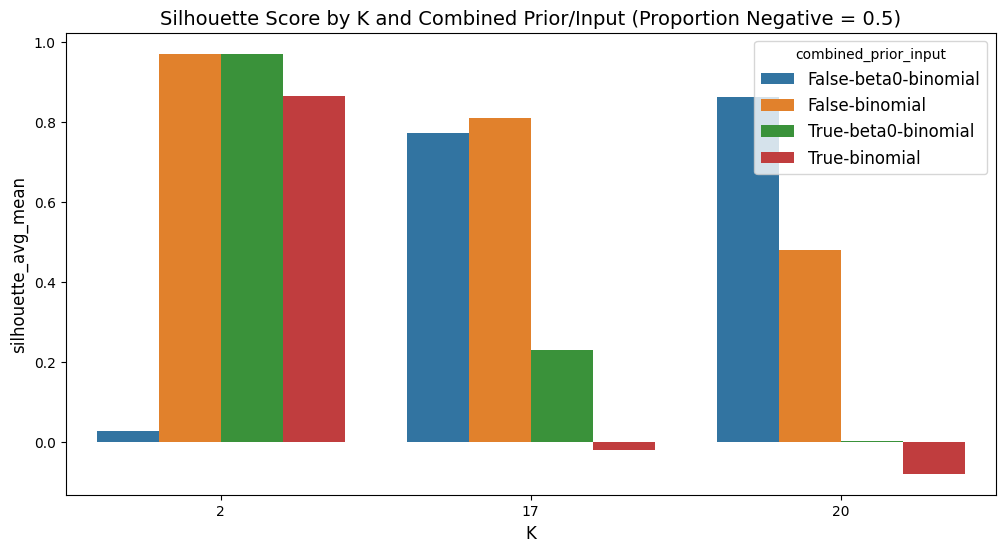

/scratch/ipykernel_964/7815854.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='K', y='silhouette_avg_mean', hue='combined_prior_input', data=grouped_0_99, ci=None)


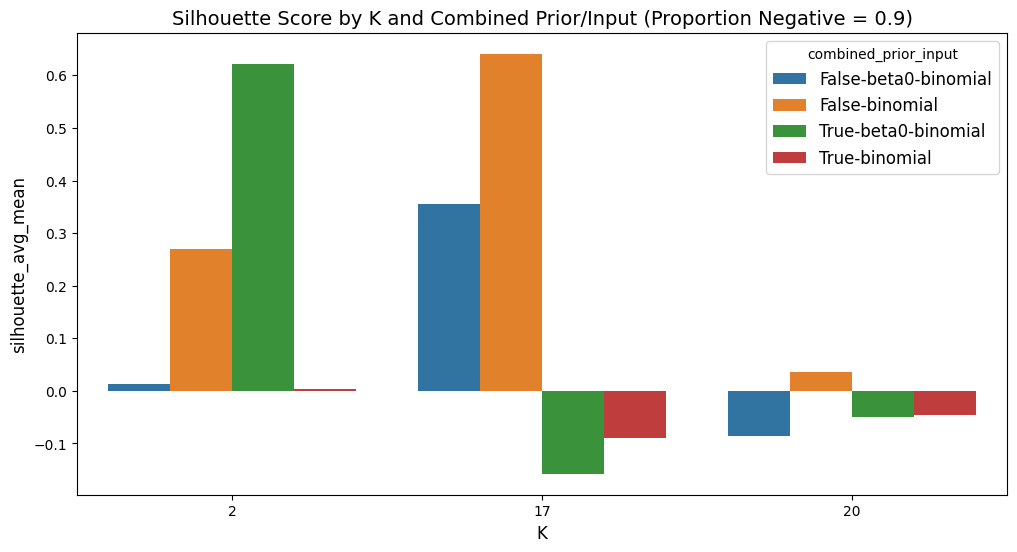

In [19]:
# Filter for proportion_negative = 0.5
grouped_0_5 = grouped_summary[grouped_summary['proportion_negative'] == 0.5]

# Filter for proportion_negative = 0.99
grouped_0_99 = grouped_summary[grouped_summary['proportion_negative'] == 0.9]

# Plot for proportion_negative = 0.5
plt.figure(figsize=(12, 6))
sns.barplot(x='K', y='silhouette_avg_mean', hue='combined_prior_input', data=grouped_0_5, ci=None)
plt.title('Silhouette Score by K and Combined Prior/Input (Proportion Negative = 0.5)')
plt.show()

# Plot for proportion_negative = 0.99
plt.figure(figsize=(12, 6))
sns.barplot(x='K', y='silhouette_avg_mean', hue='combined_prior_input', data=grouped_0_99, ci=None)
plt.title('Silhouette Score by K and Combined Prior/Input (Proportion Negative = 0.9)')
plt.show()


/scratch/ipykernel_964/3161220735.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='K', y='avg_corr_mean', hue='combined_prior_input', data=grouped_0_5, ci=None)


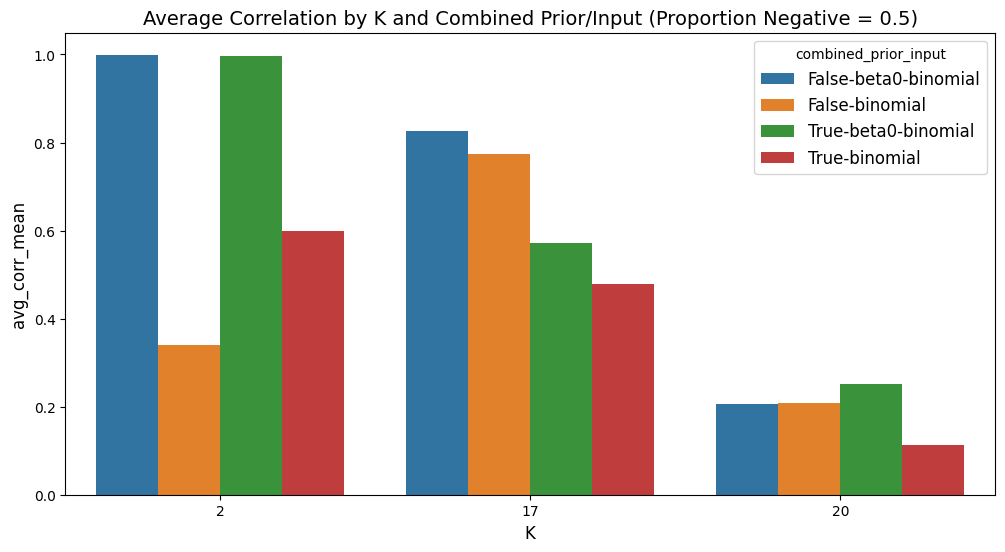

/scratch/ipykernel_964/3161220735.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='K', y='avg_corr_mean', hue='combined_prior_input', data=grouped_0_99, ci=None)


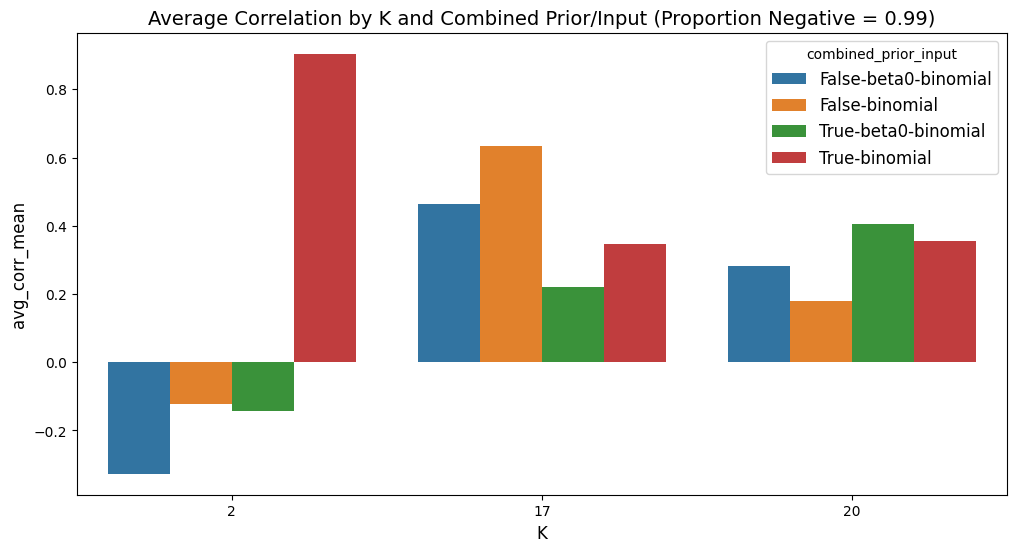

In [20]:
# Plot for proportion_negative = 0.5 (avg_corr_mean)
plt.figure(figsize=(12, 6))
sns.barplot(x='K', y='avg_corr_mean', hue='combined_prior_input', data=grouped_0_5, ci=None)
plt.title('Average Correlation by K and Combined Prior/Input (Proportion Negative = 0.5)')
plt.show()

# Plot for proportion_negative = 0.99 (avg_corr_mean)
plt.figure(figsize=(12, 6))
sns.barplot(x='K', y='avg_corr_mean', hue='combined_prior_input', data=grouped_0_99, ci=None)
plt.title('Average Correlation by K and Combined Prior/Input (Proportion Negative = 0.99)')
plt.show()
